# DQN Epsilon Decay Ablation Study

This notebook tests how different epsilon decay rates affect DQN performance on LunarLander. We'll train multiple agents with varying epsilon_decay values and compare their learning curves and final performance.

**Baseline:** epsilon_decay = 0.995

## 1. Setup and Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys

# Import from vanilla DQN module

import sys
import os
sys.path.insert(0, os.path.abspath('..'))

from core.vanilla_dqn_lunar_lander import VanillaDQN, device,save_results, save_model, save_plot

from gymnasium import make

Using device: cpu


## 2. Training Function (Adapted from Vanilla)

In [2]:
def train_dqn(num_episodes=100, batch_size=32, update_frequency=4, target_update_frequency=100,
              epsilon_decay=0.995, verbose=True):
    """Train the DQN agent on LunarLander"""

    # Create environment
    env = make('LunarLander-v3')
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    # Create agent with specified epsilon_decay
    agent = VanillaDQN(state_dim, action_dim, epsilon_decay=epsilon_decay)

    # Training loop
    episode_rewards = []
    episode_losses = []
    epsilon_history = []

    for episode in range(num_episodes):
        state, _ = env.reset()
        episode_reward = 0
        episode_loss = []
        done = False
        step = 0

        while not done:
            # Select and execute action
            action = agent.select_action(state, training=True)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Store transition
            agent.store_transition(state, action, reward, next_state, done)

            # Update network
            if step % update_frequency == 0:
                loss = agent.update(batch_size)
                if loss is not None:
                    episode_loss.append(loss)

            episode_reward += reward
            state = next_state
            step += 1

        # Update target network
        if (episode + 1) % target_update_frequency == 0:
            agent.update_target_network()

        # Decay epsilon
        agent.decay_epsilon()

        # Record metrics
        episode_rewards.append(episode_reward)
        epsilon_history.append(agent.epsilon)
        if episode_loss:
            episode_losses.append(np.mean(episode_loss))

        # Print progress
        if verbose and (episode + 1) % 25 == 0:
            avg_reward = np.mean(episode_rewards[-25:])
            print(f"  Episode {episode + 1}/{num_episodes} | Avg Reward (last 25): {avg_reward:.2f} | Epsilon: {agent.epsilon:.4f}")

    env.close()

    return agent, episode_rewards, episode_losses, epsilon_history

## 3. Ablation Study: Test Multiple Epsilon Decay Values

In [3]:
# Epsilon decay values to test
epsilon_decay_values = [0.45,0.50,0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90, 0.95, 0.99, 0.995, 0.999]
num_episodes = 500

# Store results
results = {}

print("="*70)
print(f"DQN Epsilon Decay Ablation Study")
print(f"Testing {len(epsilon_decay_values)} epsilon_decay values over {num_episodes} episodes")
print("="*70)

for epsilon_decay in epsilon_decay_values:
    agent, rewards, losses,epsilon_history = train_dqn(num_episodes=500, epsilon_decay=epsilon_decay)

    hyperparameters = {
        'learning_rate': 1e-3,
        'num_layers': 2,
        'hidden_dim': 128,
        'epsilon_decay': epsilon_decay,
        'batch_size': 32,
        'num_episodes': 100
    }

    # Results saved to: results/ablations/epsilon_decay/{epsilon_decay}/
    save_results(agent, rewards, losses, hyperparameters,
                 experiment_name='epsilon_decay', variant_name=str(epsilon_decay))
    save_model(agent, experiment_name='epsilon_decay', variant_name=str(epsilon_decay))
    save_plot(rewards, losses, experiment_name='epsilon_decay', variant_name=str(epsilon_decay))

    results[epsilon_decay] = {
        'agent': agent,
        'rewards': rewards,
        'losses': losses,
        'epsilon_history': epsilon_history
    }

print("\n" + "="*70)
print("Training Complete!")
print("="*70)

DQN Epsilon Decay Ablation Study
Testing 14 epsilon_decay values over 500 episodes
  Episode 25/500 | Avg Reward (last 25): -320.26 | Epsilon: 0.0100
  Episode 50/500 | Avg Reward (last 25): -367.49 | Epsilon: 0.0100
  Episode 75/500 | Avg Reward (last 25): -225.76 | Epsilon: 0.0100
  Episode 100/500 | Avg Reward (last 25): -291.71 | Epsilon: 0.0100
  Episode 125/500 | Avg Reward (last 25): -343.90 | Epsilon: 0.0100
  Episode 150/500 | Avg Reward (last 25): -282.53 | Epsilon: 0.0100
  Episode 175/500 | Avg Reward (last 25): -299.25 | Epsilon: 0.0100
  Episode 200/500 | Avg Reward (last 25): -408.02 | Epsilon: 0.0100
  Episode 225/500 | Avg Reward (last 25): -260.10 | Epsilon: 0.0100
  Episode 250/500 | Avg Reward (last 25): -110.53 | Epsilon: 0.0100
  Episode 275/500 | Avg Reward (last 25): -137.34 | Epsilon: 0.0100
  Episode 300/500 | Avg Reward (last 25): -206.28 | Epsilon: 0.0100
  Episode 325/500 | Avg Reward (last 25): -43.92 | Epsilon: 0.0100
  Episode 350/500 | Avg Reward (last 

## 4. Summary Statistics

In [4]:
# Calculate summary statistics
summary_data = []

for eps_decay in epsilon_decay_values:
    rewards = results[eps_decay]['rewards']
    
    summary_data.append({
        'Epsilon Decay': eps_decay,
        'Best Reward': max(rewards),
        'Final Avg (last 25)': np.mean(rewards[-25:]),
        'Mean Reward': np.mean(rewards),
        'Std Dev': np.std(rewards),
        'Initial Avg (first 25)': np.mean(rewards[:25])
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)


SUMMARY
 Epsilon Decay  Best Reward  Final Avg (last 25)  Mean Reward    Std Dev  Initial Avg (first 25)
         0.450   301.125329            13.236570  -166.707227 226.961226             -320.264670
         0.500   285.045717           -60.258150  -105.806936 224.210377             -335.297749
         0.550   283.916955            38.919054  -108.769465 177.396610             -170.992919
         0.600   280.221157           101.855936  -134.960990 228.239894             -454.732647
         0.650   284.262991            92.237191   -91.739762 185.918244             -202.134964
         0.700   282.603547            14.620758  -131.737327 183.375314             -281.321247
         0.750   272.755655           -92.248754  -202.181654 234.489767             -418.957798
         0.800   247.536818           -27.090011  -203.029656 186.859408             -206.460611
         0.850   296.246931            53.506591   -77.287035 227.220453             -260.014467
         0.900   282.

**Stability of the model**

While a purely statistical glance at the summary table shows that epsilon_decay = 0.999 yields the lowest standard deviation, this reflects an illusion of stability. Because a decay rate of 0.999 keeps exploration excessively high throughout all 500 episodes, the agent fails to converge on a viable strategy. Its low variance merely indicates that it is consistently failing and receiving uniform negative penalties, resulting in a flat, mediocre learning trajectory. True learning instability is instead exemplified by 0.70, which exhibits wild, unpredictable reward swings without consolidating a clear policy.

## 5. Visualization: Individual Training Curves

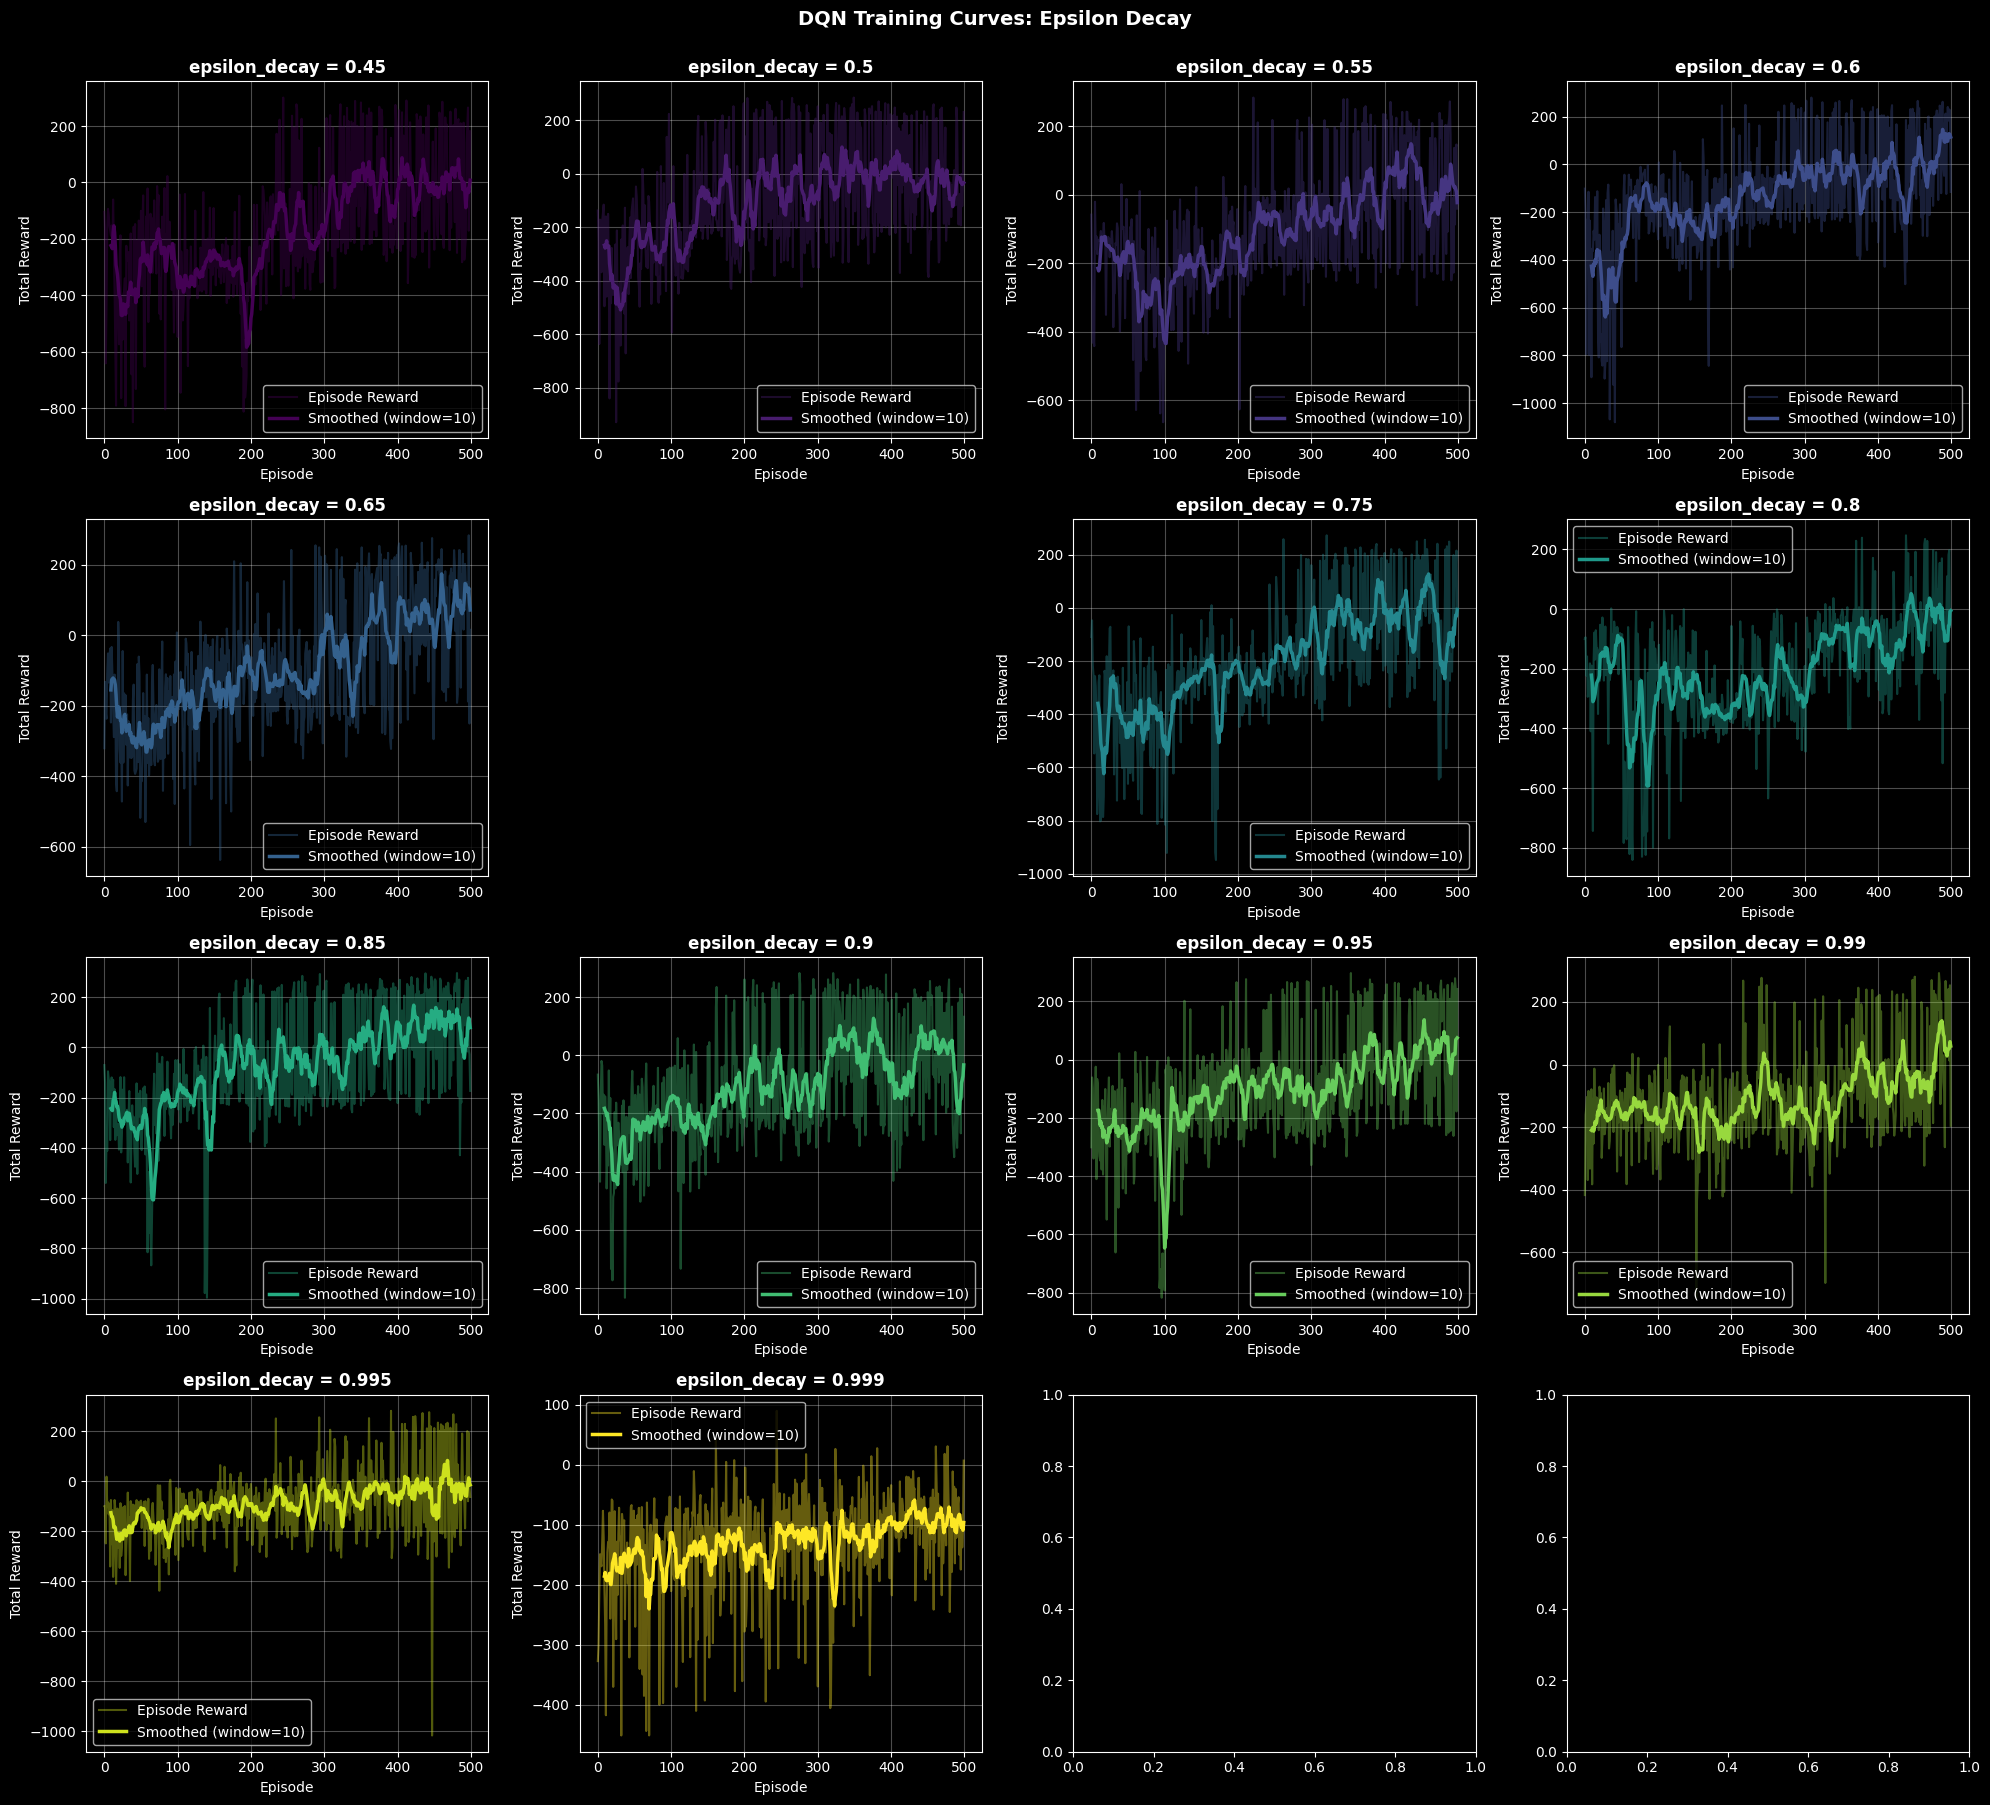

In [6]:
## 5. Visualization: Individual Training Curves
# Plot individual training curves for each epsilon_decay
num_values = len(epsilon_decay_values)
cols = 4  # 4 columns
rows = (num_values + cols - 1) // cols  # Calculate rows needed (ceiling division)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4.5))
axes = axes.flatten()  # Flatten to 1D array for easy indexing

colors = plt.cm.viridis(np.linspace(0, 1, num_values))

for idx, eps_decay in enumerate(epsilon_decay_values):
    ax = axes[idx]
    rewards = results[eps_decay]['rewards']

    # Raw rewards
    ax.plot(rewards, alpha=0.4, color=colors[idx], label='Episode Reward')

    # Smoothed rewards (window=10)
    window = 10
    smoothed = np.convolve(rewards, np.ones(window) / window, mode='valid')
    ax.plot(range(window - 1, len(rewards)), smoothed, color=colors[idx],
            linewidth=2.5, label=f'Smoothed (window={window})')

    ax.set_title(f'epsilon_decay = {eps_decay}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.grid(True, alpha=0.3)
    ax.legend()

# Remove extra subplot
fig.delaxes(axes[5])

plt.suptitle('DQN Training Curves: Epsilon Decay', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Analysis of Training Curves Across Epsilon Decay Values**

**Late-Stage Improvers (epsilon decay = 0.55, 0.6, 0.65, 0.75,0.85)**
Despite negative rewards during episodes 0–300, these configurations exhibit a pronounced positive slope trend. This pattern suggests that their learning trajectory is still improving and would likely benefit from extended training periods. The initial decline followed by recovery indicates they are recovering from early exploration phases.

**Stagnant Learners (epsilon decay = 0.995, 0.999)**
These values maintain nearly flat reward trends through 400 episodes, remaining predominantly negative. Although random fluctuations appear in later episodes due to variance, this inconsistency does not reflect meaningful progress. Compared to other epsilon decay rates, these configurations show less promising learning dynamics (Tammewar et al., 2023).

**Moderate Recoverers (epsilon decay = 0.99, 0.8, 0.95, 0.7)**
These curves maintain stable, flat performance for the first 300 episodes, then show a sharp upward trend with improved from negative, the 300 episodes, to positive trend. This pattern suggests these configurations require a "warm-up" period before becoming effective, and extended training could yield significant improvements.

**Increasing and drop off (0.9)**
This curve demonstrates a delayed recovery pattern. During the first 300 episodes, the agent exhibits an upward learning trend (positive slope) while remaining in negative rewards. This indicates a trade-off scenario. The relatively high decay rate causes the agent to shift from exploration to exploitation quickly, which allows some learning progress initially. However, this early commitment to exploitation prevents it from discovering better strategies, leading to a plateau. The eventual improvement suggests the agent does find viable solutions, but this comes too late to recover overall training performance.

## 6. Visualization: Comparison of Final Performance

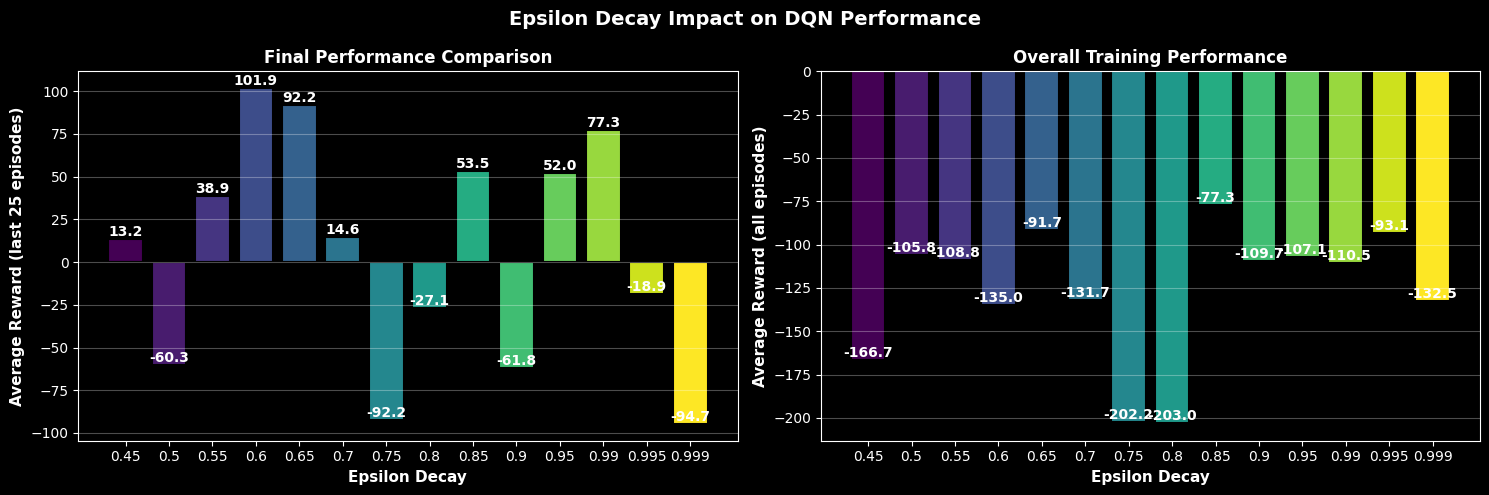

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Final Average Reward (last 25 episodes)
final_avgs = [np.mean(results[eps]['rewards'][-25:]) for eps in epsilon_decay_values]
colors_bar = plt.cm.viridis(np.linspace(0, 1, len(epsilon_decay_values)))

bars1 = axes[0].bar(range(len(epsilon_decay_values)), final_avgs, color=colors_bar, edgecolor='black', linewidth=1.5)
axes[0].set_xticks(range(len(epsilon_decay_values)))
axes[0].set_xticklabels([f'{eps}' for eps in epsilon_decay_values])
axes[0].set_xlabel('Epsilon Decay', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Average Reward (last 25 episodes)', fontsize=11, fontweight='bold')
axes[0].set_title('Final Performance Comparison', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars1, final_avgs):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Mean Reward (entire training)
mean_rewards = [np.mean(results[eps]['rewards']) for eps in epsilon_decay_values]

bars2 = axes[1].bar(range(len(epsilon_decay_values)), mean_rewards, color=colors_bar, edgecolor='black', linewidth=1.5)
axes[1].set_xticks(range(len(epsilon_decay_values)))
axes[1].set_xticklabels([f'{eps}' for eps in epsilon_decay_values])
axes[1].set_xlabel('Epsilon Decay', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Average Reward (all episodes)', fontsize=11, fontweight='bold')
axes[1].set_title('Overall Training Performance', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars2, mean_rewards):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Epsilon Decay Impact on DQN Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Epsilon Decay Impact: Final vs. Overall Training Performance**

The left graph reveals that epsilon decay = 0.6, 0.65, and 0.99 achieve the strongest final performance (tallest bars), while 0.999, 0.75, and 0.9 perform worst in the last 25 episodes. However, this ranking diverges dramatically when examining overall training performance (right graph), where 0.75, 0.8, and 0.45  emerge as the worst performers. This mismatch reveals a critical insight: late improvement cannot compensate for poor cumulative learning.

epsilon decay = 0.6 exemplifies this trade-off. Despite strong final-episode recovery, the accumulated negative rewards throughout the entire training period far outweigh this late gain, resulting in poor overall training performance.

The optimal performers are epsilon decay = 0.65, 0.6, 0.85 and 0.99. They achieve excellent final performance while maintaining the least negative cumulative rewards across all episodes. Their success stems not from dramatic late recovery, but from stable performance throughout training—they balance short-term gains with long-term learning efficiency.


## 7. Visualization: Exploration Decay Over Time

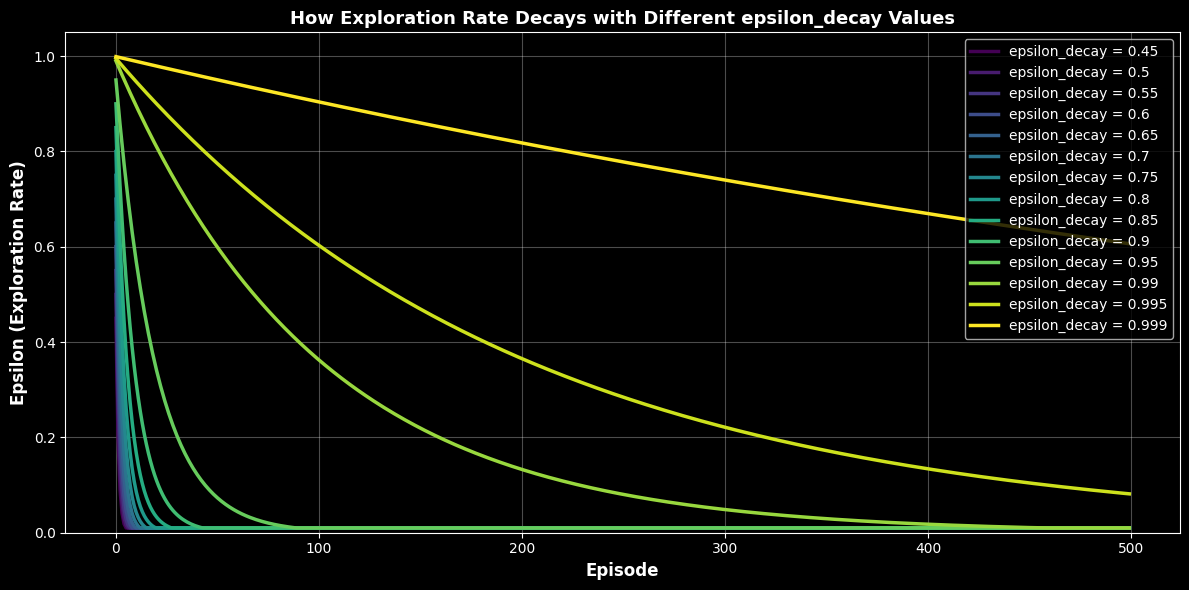


Epsilon Decay Analysis:
- Faster decay (0.90): Exploration stops quickly, exploits more
- Slower decay (0.999): Exploration continues longer, explores more
- Baseline (0.995): Good balance between exploration and exploitation


In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(epsilon_decay_values)))

for idx, eps_decay in enumerate(epsilon_decay_values):
    epsilon_history = results[eps_decay]['epsilon_history']
    ax.plot(epsilon_history, linewidth=2.5, label=f'epsilon_decay = {eps_decay}', color=colors[idx])

ax.set_xlabel('Episode', fontsize=12, fontweight='bold')
ax.set_ylabel('Epsilon (Exploration Rate)', fontsize=12, fontweight='bold')
ax.set_title('How Exploration Rate Decays with Different epsilon_decay Values', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()


**Exploration Rate Decay**

Where y = 0 represents pure exploitation and y = 1 represents pure exploration, this graph shows how different epsilon decay values control the exploration-exploitation transition.

Almost all epsilon_decay values drop steeply in the first 100 episodes, transitioning from full exploration (y=1.0) toward exploitation. The critical difference lies in what happens after episode 100:

Low epsilon decay (0.45–0.95 - dark purple/green lines): Reach near-zero exploration by episode ~100 and stay there. The agent commits to exploitation early and never explores again.

Medium epsilon decay (0.99 - light green): Continue dropping gradually after episode 100, reaching near-zero by episode ~400. This provides a longer exploitation-learning window before committing fully.

High epsilon decay (0.995-0.999 - yellow line): Drop much more slowly after episode 100, maintaining 10-30% exploration even at episode 500. The agent keeps a "safety margin" of exploration throughout.


## 8. Visualization: Overlaid Reward Curves

In [4]:
final_epsilon_decay_values = [0.99, 0.65, 0.85]


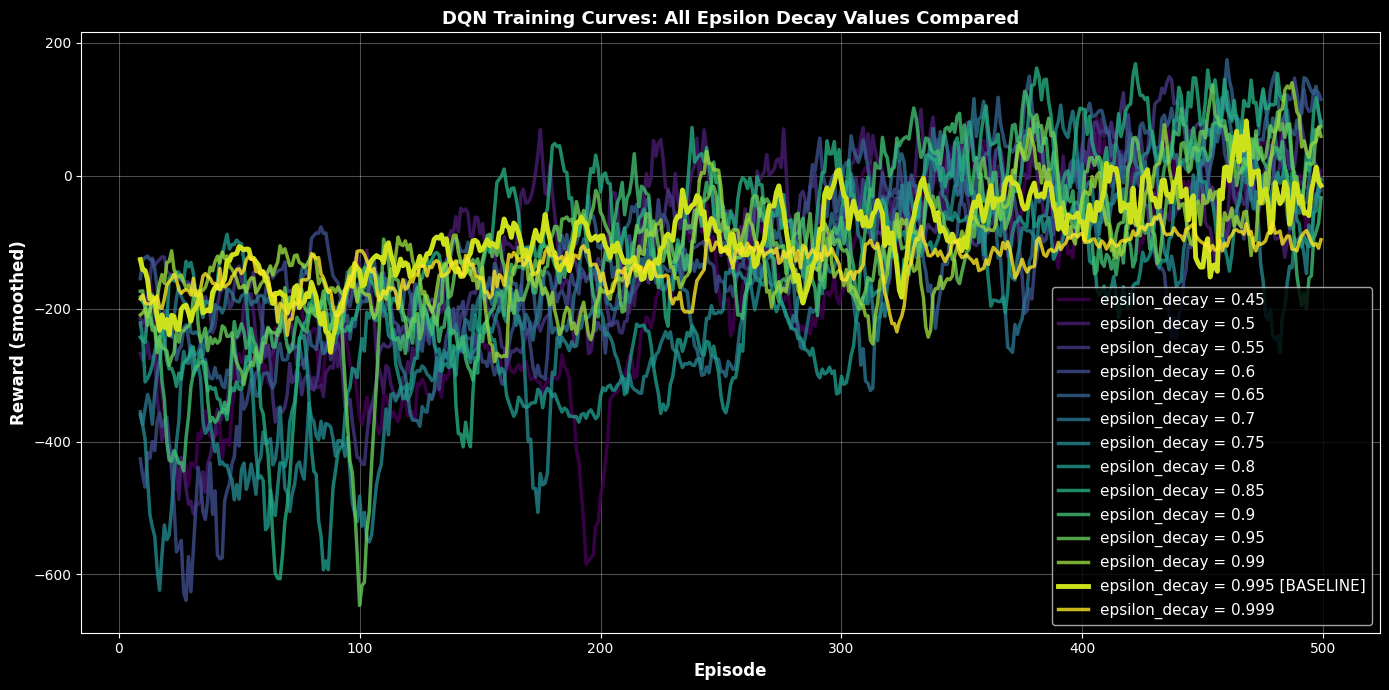

In [9]:
fig, ax = plt.subplots(figsize=(14, 7))

colors = plt.cm.viridis(np.linspace(0, 1, len(final_epsilon_decay_values)))

for idx, eps_decay in enumerate(final_epsilon_decay_values):
    rewards = results[eps_decay]['rewards']

    # Smoothed rewards (window=10)
    window = 10
    smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')

    # Highlight baseline (0.995)
    linewidth = 3.5 if eps_decay == 0.995 else 2.5
    alpha = 1.0 if eps_decay == 0.995 else 0.8

    ax.plot(range(window-1, len(rewards)), smoothed, linewidth=linewidth,
            label=f'epsilon_decay = {eps_decay}' + (' [BASELINE]' if eps_decay == 0.995 else ''),
            color=colors[idx], alpha=alpha)

ax.set_xlabel('Episode', fontsize=12, fontweight='bold')
ax.set_ylabel('Reward (smoothed)', fontsize=12, fontweight='bold')
ax.set_title('DQN Training Curves: All Epsilon Decay Values Compared', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary

Loaded 0.995
Loaded 0.7
Loaded 0.99
Loaded 0.85
Loaded 0.6
Loaded 0.65


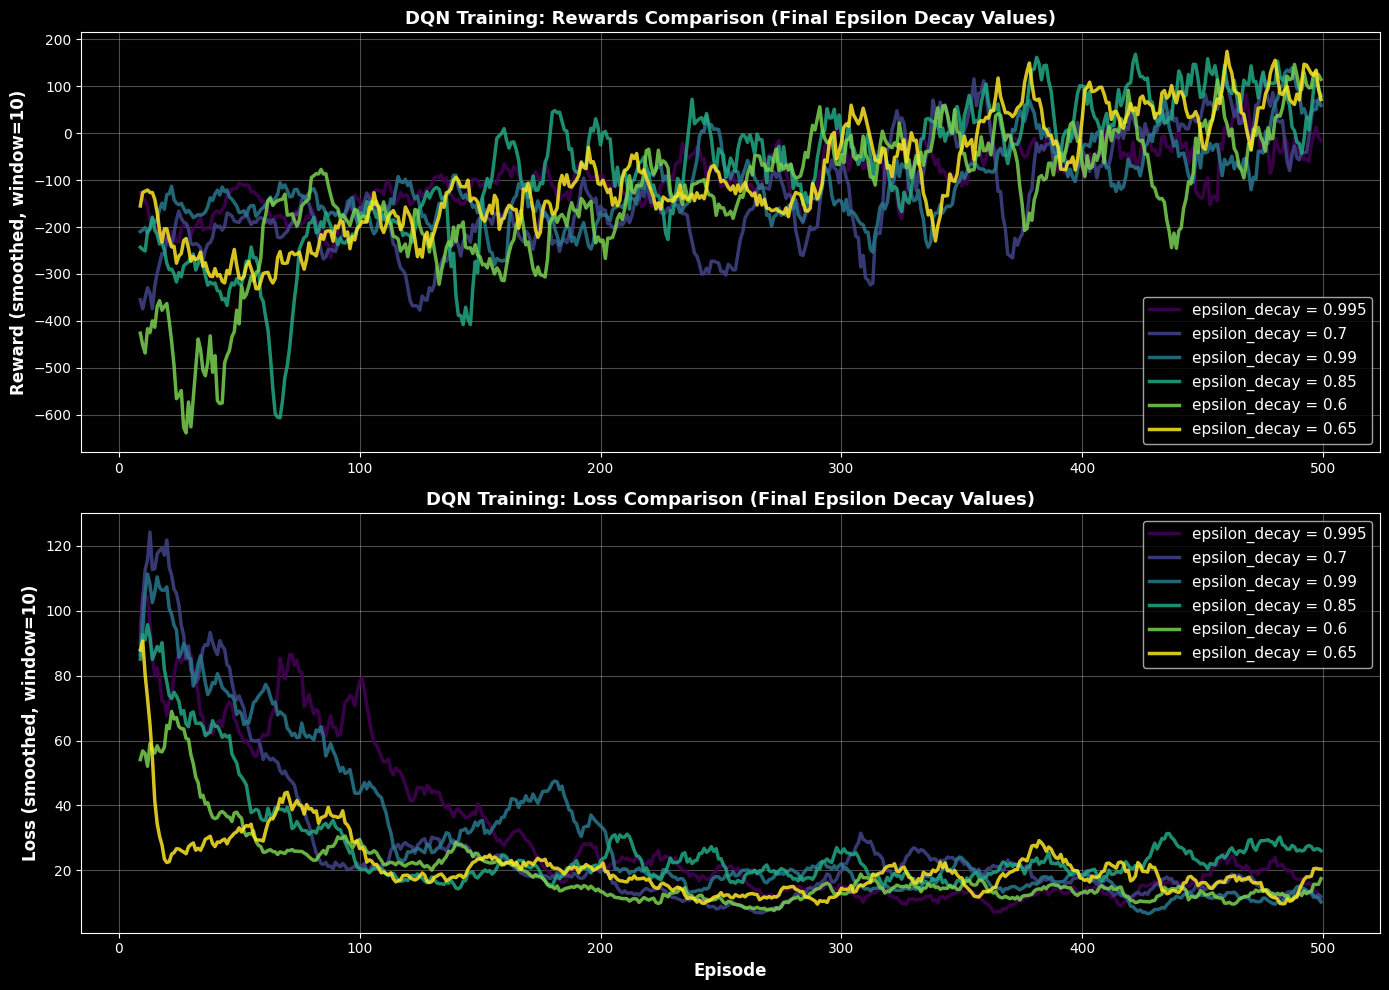

In [8]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

# Base path to your results (adjust if needed)
base_path = r"D:\2026-1\Deep Learning\finalProject\Project\GitHubProject\COMP3242-Group-Project-DQN\results\ablations\epsilon_decay"

final_epsilon_decay_values = [0.995,0.7,0.99, 0.85,0.60, 0.65]

# Load results from each folder
results = {}
for eps_decay in final_epsilon_decay_values:
    pkl_path = os.path.join(base_path, str(eps_decay), "results.pkl")
    with open(pkl_path, 'rb') as f:
        results[eps_decay] = pickle.load(f)
    print(f"Loaded {eps_decay}")

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

colors = plt.cm.viridis(np.linspace(0, 1, len(final_epsilon_decay_values)))

for idx, eps_decay in enumerate(final_epsilon_decay_values):
    rewards = results[eps_decay]['episode_rewards']
    losses = results[eps_decay]['episode_losses']

    # Smoothed curves (window=10)
    window = 10
    smoothed_rewards = np.convolve(rewards, np.ones(window)/window, mode='valid')
    smoothed_losses = np.convolve(losses, np.ones(window)/window, mode='valid')

    episodes = range(window-1, len(rewards))

    # Plot Rewards (top subplot)
    ax1.plot(episodes, smoothed_rewards, linewidth=2.5,
            label=f'epsilon_decay = {eps_decay}', color=colors[idx], alpha=0.85)

    # Plot Loss (bottom subplot)
    ax2.plot(episodes, smoothed_losses, linewidth=2.5,
            label=f'epsilon_decay = {eps_decay}', color=colors[idx], alpha=0.85)

# Rewards subplot
ax1.set_ylabel('Reward (smoothed, window=10)', fontsize=12, fontweight='bold')
ax1.set_title('DQN Training: Rewards Comparison (Final Epsilon Decay Values)', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right', fontsize=11)
ax1.grid(True, alpha=0.3)

# Loss subplot
ax2.set_xlabel('Episode', fontsize=12, fontweight='bold')
ax2.set_ylabel('Loss (smoothed, window=10)', fontsize=12, fontweight='bold')
ax2.set_title('DQN Training: Loss Comparison (Final Epsilon Decay Values)', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r"D:\2026-1\Deep Learning\finalProject\Project\GitHubProject\COMP3242-Group-Project-DQN\final_comparison_rewards_losses.png", dpi=300)
plt.show()

This graphic highlights the training dynamics of our top-performing epsilon decay configurations (0.60, 0.65, 0.85 and 0.99).

For the fast-decaying rates (0.60, 0.65 and 0.85), the exploration phase terminates within the first 50 to 100 episodes. Because the agent transitions to near-pure exploitation early on, the loss curves drop rapidly and stabilize. This happens because the agent restricts its experiences to a familiar subset of states, allowing the network to quickly minimize TD-error. For LunarLander, this aggressive transition worked remarkably well, allowing the agent to spend over 400 episodes optimizing its landing trajectories, yielding the highest final rewards.

Conversely, epsilon_decay = 0.99 represents a more traditional, prolonged exploration strategy. The agent continues to take a significant amount of random actions deep into training. This prevents the loss from dropping as quickly as the fast-decay variants and causes the reward curve to remain negative for the first 300 episodes. However, once exploration finally bottoms out near episode 400, the agent successfully settles into a robust strategy, achieving a strong positive final reward (77.3).

In this environment, the agent is capable of discovering a safe landing strategy very quickly. Therefore, forcing extended exploration via very high decay rates (like 0.995 or 0.999) wastes training time on random actions, whereas rapidly capping exploration (0.60 and 0.65) allows the agent to maximize its final optimization window.